# 04 LiDAR Velocity Analysis

## 1. Purpose and Scope

This notebook analyses the LiDAR information available for target-vehicle motion analysis in TruckScenes.

The annotation-derived reference velocity from `02_Annotation_Reference_Velocity.ipynb` is reused as the vehicle-speed reference.

Previous dataset inspection showed that LiDAR provides spatial coordinates, intensity, and timestamp information, but no direct velocity field. Therefore, this notebook first analyses target-associated LiDAR information and then constructs a LiDAR-derived target-velocity baseline from changes in target position across consecutive keyframes. This derived velocity is an estimated motion quantity rather than a direct velocity measurement provided by the LiDAR sensor.

The main workflow is:

LiDAR validation  
→ target association  
→ target-level information  
→ reference-speed alignment  
→ speed-conditioned analysis

Only keyframe LiDAR observations are used in the current workflow.


## 2. Validate LiDAR Data

This section validates the LiDAR point-cloud structure and timing information required for the later target-level analysis.

The validation focuses only on the information needed for LiDAR loading, keyframe alignment, and target association.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np

%load_ext autoreload
%autoreload 2

from pyquaternion import Quaternion
from truckscenes.utils.data_classes import Box
from truckscenes.utils.geometry_utils import points_in_box
from src.config import SAMPLES_ROOT, METADATA_ROOT, SENSOR_ROOT
from src.data_io import load_json, read_pcd_header
from src.sensor_observation import build_sensor_data_df
from src.lidar_velocity import (
    load_lidar_points,
    build_target_lidar_information_df,
)

In [2]:
records = []

for sensor_folder in sorted(SAMPLES_ROOT.glob("LIDAR*")):

    pcd_file = next(sensor_folder.glob("*.pcd"))

    header = read_pcd_header(pcd_file)

    records.append({
        "Sensor": sensor_folder.name,
        "Fields": header["FIELDS"],
        "Size": header["SIZE"],
        "Type": header["TYPE"],
        "Data": header["DATA"],
        "Points": header["POINTS"],
    })


lidar_pcd_check = pd.DataFrame(records)

display(lidar_pcd_check)

,Sensor,Fields,Size,Type,Data,Points
0,LIDAR_LEFT,x y z intensity timestamp,4 4 4 4 8,F F F F U,binary_compressed,80729
1,LIDAR_REAR,x y z intensity timestamp,4 4 4 4 8,F F F F U,binary_compressed,17262
2,LIDAR_RIGHT,x y z intensity timestamp,4 4 4 4 8,F F F F U,binary_compressed,81221
3,LIDAR_TOP_FRONT,x y z intensity timestamp,4 4 4 4 8,F F F F U,binary_compressed,17458
4,LIDAR_TOP_LEFT,x y z intensity timestamp,4 4 4 4 8,F F F F U,binary_compressed,23344
5,LIDAR_TOP_RIGHT,x y z intensity timestamp,4 4 4 4 8,F F F F U,binary_compressed,22034


All six LiDAR channels use the same PCD structure. Each point contains x, y, z, intensity, and timestamp information, but no direct velocity field.

The LiDAR files therefore provide spatial and temporal information that may support motion analysis, rather than a direct vehicle-velocity measurement.

In [3]:
pcd_file = next(
    (SAMPLES_ROOT / "LIDAR_LEFT").glob("*.pcd")
)

lidar_points_df = load_lidar_points(pcd_file)

print("Shape:", lidar_points_df.shape)
print("Columns:", lidar_points_df.columns.tolist())

display(lidar_points_df.head())

Shape: (80729, 5)
Columns: ['x', 'y', 'z', 'intensity', 'timestamp']


,x,y,z,intensity,timestamp
0,-3.025575,-3.496517,-2.151803,0.003922,1692868171726117
1,-3.022805,-3.518060,-2.158554,0.007843,1692868171726061
2,-3.029337,-3.550661,-2.172055,0.007843,1692868171726005
3,-3.014580,-3.558447,-2.170367,0.007843,1692868171725950
4,-3.004475,-3.571723,-2.172055,0.007843,1692868171725894


In [4]:
sensor_data_df = build_sensor_data_df()

lidar_observation_df = (
    sensor_data_df[
        (sensor_data_df["Modality"] == "LiDAR")
        & (sensor_data_df["Data Group"] == "samples")
    ]
    .copy()
)

samples = load_json(
    METADATA_ROOT / "sample.json"
)

sample_timestamp = {
    sample["token"]: sample["timestamp"]
    for sample in samples
}

lidar_observation_df["sample_timestamp_us"] = (
    lidar_observation_df["Sample Token"]
    .map(sample_timestamp)
)

lidar_observation_df["timestamp_offset_ms"] = (
    (
        lidar_observation_df["Timestamp"]
        - lidar_observation_df["sample_timestamp_us"]
    ).abs()
    / 1000
)

print(
    "LiDAR keyframe observations:",
    len(lidar_observation_df),
)

print(
    "Median absolute offset (ms):",
    lidar_observation_df["timestamp_offset_ms"].median(),
)

print(
    "Maximum absolute offset (ms):",
    lidar_observation_df["timestamp_offset_ms"].max(),
)

LiDAR keyframe observations: 2400
Median absolute offset (ms): 18.9585
Maximum absolute offset (ms): 49.539


LiDAR keyframe observations are closely aligned with their linked annotation samples, with a median absolute timestamp offset of approximately 19 ms and a maximum offset below 50 ms.

The current target-level analysis therefore uses keyframe LiDAR observations and their linked sample annotations.

In [5]:
annotations = load_json(
    METADATA_ROOT / "sample_annotation.json"
)

print("Number of annotations:", len(annotations))

print(
    "num_lidar_pts available:",
    all(
        "num_lidar_pts" in annotation
        for annotation in annotations
    )
)

Number of annotations: 25750
num_lidar_pts available: True


## 3. Align and Associate LiDAR with Target Vehicles

LiDAR points are associated with annotated targets by transforming each global annotation box into the coordinate frame of the corresponding LiDAR sensor and selecting points inside the transformed box.

Before applying this workflow to all target vehicles, the association is validated against the metadata `num_lidar_pts` field.

In [6]:
sample_data = load_json(
    METADATA_ROOT / "sample_data.json"
)

ego_poses = load_json(
    METADATA_ROOT / "ego_pose.json"
)

calibrated_sensors = load_json(
    METADATA_ROOT / "calibrated_sensor.json"
)


sample_data_lookup = {
    record["token"]: record
    for record in sample_data
}

ego_pose_lookup = {
    record["token"]: record
    for record in ego_poses
}

calibrated_sensor_lookup = {
    record["token"]: record
    for record in calibrated_sensors
}


# Select one annotation with LiDAR points
annotation = next(
    ann
    for ann in annotations
    if ann["num_lidar_pts"] > 0
)

sample_token = annotation["sample_token"]

lidar_frames = lidar_observation_df[
    lidar_observation_df["Sample Token"] == sample_token
]


counts = []

for _, frame in lidar_frames.iterrows():

    sd = sample_data_lookup[
        frame["Token"]
    ]

    ego_pose = ego_pose_lookup[
        sd["ego_pose_token"]
    ]

    calibrated_sensor = calibrated_sensor_lookup[
        sd["calibrated_sensor_token"]
    ]

    lidar_points = load_lidar_points(
        SENSOR_ROOT / sd["filename"]
    )

    box = Box(
        annotation["translation"],
        annotation["size"],
        Quaternion(annotation["rotation"]),
    )

    # Global -> ego frame
    box.translate(
        -np.asarray(
            ego_pose["translation"],
            dtype=float,
        )
    )

    box.rotate(
        Quaternion(
            ego_pose["rotation"]
        ).inverse
    )

    # Ego -> LiDAR sensor frame
    box.translate(
        -np.asarray(
            calibrated_sensor["translation"],
            dtype=float,
        )
    )

    box.rotate(
        Quaternion(
            calibrated_sensor["rotation"]
        ).inverse
    )

    inside_box = points_in_box(
        box,
        lidar_points[
            ["x", "y", "z"]
        ].to_numpy().T,
    )

    counts.append({
        "Sensor": frame["Sensor"],
        "Point Count": int(
            inside_box.sum()
        ),
    })


lidar_count_check = pd.DataFrame(
    counts
)

display(lidar_count_check)

print(
    "Sum across LiDAR sensors:",
    lidar_count_check[
        "Point Count"
    ].sum(),
)

print(
    "Metadata num_lidar_pts:",
    annotation["num_lidar_pts"],
)

,Sensor,Point Count
0,LIDAR_LEFT,362
1,LIDAR_RIGHT,152
2,LIDAR_TOP_FRONT,0
3,LIDAR_TOP_LEFT,3
4,LIDAR_TOP_RIGHT,2
5,LIDAR_REAR,0


Sum across LiDAR sensors: 519
Metadata num_lidar_pts: 430


In [7]:
sample_time = sample_timestamp[
    sample_token
]

timestamp_records = []

for _, frame in lidar_frames.iterrows():

    sd = sample_data_lookup[
        frame["Token"]
    ]

    lidar_points = load_lidar_points(
        SENSOR_ROOT / sd["filename"]
    )

    timestamp_records.append({
        "Sensor": frame["Sensor"],

        "sample_offset_ms": (
            sd["timestamp"]
            - sample_time
        ) / 1000,

        "point_min_offset_ms": (
            lidar_points["timestamp"].min()
            - sample_time
        ) / 1000,

        "point_max_offset_ms": (
            lidar_points["timestamp"].max()
            - sample_time
        ) / 1000,
    })


lidar_time_check = pd.DataFrame(
    timestamp_records
)

display(
    lidar_time_check.round(3)
)

,Sensor,sample_offset_ms,point_min_offset_ms,point_max_offset_ms
0,LIDAR_LEFT,-10.661,-49.830,28.509
1,LIDAR_RIGHT,14.718,-24.423,53.860
2,LIDAR_TOP_FRONT,2.642,-32.213,37.497
3,LIDAR_TOP_LEFT,-22.296,-57.453,12.861
4,LIDAR_TOP_RIGHT,27.979,-7.094,63.053
5,LIDAR_REAR,-48.185,-73.192,-23.178


The raw point-in-box count did not exactly reproduce the metadata `num_lidar_pts` value.

Point-level timestamps show that the six LiDAR observations are not perfectly synchronized and that individual LiDAR scans span several tens of milliseconds around the annotation sample time. Therefore, directly applying a single static annotation box to all raw LiDAR points does not provide a sufficiently validated reconstruction of the metadata target-point count.

For the current keyframe analysis, `num_lidar_pts` is therefore used as the target-associated LiDAR information count. Raw point-level association is not used as the primary target-information metric.

## 4. Build Target-Level LiDAR Information

Target-level LiDAR information is represented using the dataset-provided `num_lidar_pts` value for each annotated vehicle keyframe.

Each row of `target_lidar_df` represents one target vehicle at one keyframe. The target-level LiDAR information is then linked to the annotation-derived reference-velocity intervals using the annotation token.

Only annotations with a valid following annotation can be assigned a reference velocity.

In [8]:
samples = load_json(
    METADATA_ROOT / "sample.json"
)

annotations = load_json(
    METADATA_ROOT / "sample_annotation.json"
)

instances = load_json(
    METADATA_ROOT / "instance.json"
)

categories = load_json(
    METADATA_ROOT / "category.json"
)

print("Samples:", len(samples))
print("Annotations:", len(annotations))
print("Instances:", len(instances))
print("Categories:", len(categories))

Samples: 400
Annotations: 25750
Instances: 1094
Categories: 27


In [9]:
target_lidar_df = build_target_lidar_information_df(
    annotations,
    instances,
    categories,
)

print(
    "Target-level LiDAR observations:",
    len(target_lidar_df),
)

print(
    "Unique target vehicles:",
    target_lidar_df["instance_token"].nunique(),
)

print(
    "Median LiDAR points per target:",
    target_lidar_df["lidar_point_count"].median(),
)

display(target_lidar_df.head())

Target-level LiDAR observations: 16501
Unique target vehicles: 758
Median LiDAR points per target: 41.0


,annotation_token,instance_token,sample_token,category,lidar_point_count
0,50873dd5195b47bc9544ac2821e054e0,163b7c695f7243779ef5e5f0fd844063,32d2bcf46e734dffb14fe2e0a823d059,vehicle.car,430
1,9f0e8f997dc647bf9a0a20c679b1804d,163b7c695f7243779ef5e5f0fd844063,deb7b3f332f042d49e7636d6e4959354,vehicle.car,567
2,2c8422f4ac674f949fa1124dcaa1fa5e,163b7c695f7243779ef5e5f0fd844063,a574551be31547e4b7c78ff87c75abb3,vehicle.car,765
3,c4d5f41838054ff581106dc5e0ed10c2,163b7c695f7243779ef5e5f0fd844063,1393759bf6ff4f8e88deff0da0dc2aca,vehicle.car,1040
4,384bb8f773d640bd851c2581d8750294,163b7c695f7243779ef5e5f0fd844063,368662645c194921b716c026347db664,vehicle.car,1418


In [10]:
from src.annotation_velocity import (
    build_annotation_trajectory_df,
    build_annotation_pairs,
    add_time_differences,
    add_position_changes,
    add_reference_velocity,
)


trajectory_df = build_annotation_trajectory_df(
    samples,
    annotations,
    instances,
    categories,
)

annotation_pairs = build_annotation_pairs(
    trajectory_df
)

annotation_pairs = add_time_differences(
    annotation_pairs
)

annotation_pairs = add_position_changes(
    annotation_pairs
)

reference_df = add_reference_velocity(
    annotation_pairs
)

vehicle_reference_df = reference_df[
    reference_df["category"].str.startswith("vehicle.")
    & (reference_df["category"] != "vehicle.ego_trailer")
].copy()


lidar_reference_df = target_lidar_df.merge(
    vehicle_reference_df[
        [
            "start_annotation_token",
            "speed_2d_mps",
            "speed_3d_mps",
        ]
    ],
    left_on="annotation_token",
    right_on="start_annotation_token",
    how="left",
)


matched = lidar_reference_df["speed_2d_mps"].notna().sum()
unmatched = lidar_reference_df["speed_2d_mps"].isna().sum()

print("Matched:", matched)
print("Unmatched:", unmatched)
print(
    "Match rate:",
    round(
        matched / len(lidar_reference_df) * 100,
        2,
    ),
    "%",
)


lidar_speed_df = (
    lidar_reference_df
    .dropna(subset=["speed_2d_mps"])
    .copy()
)

print(
    "Valid LiDAR speed observations:",
    len(lidar_speed_df),
)

Matched: 15743
Unmatched: 758
Match rate: 95.41 %
Valid LiDAR speed observations: 15743


In [11]:
annotation_next = {
    ann["token"]: ann["next"]
    for ann in annotations
}

unmatched_df = lidar_reference_df[
    lidar_reference_df["speed_2d_mps"].isna()
].copy()

unmatched_df["next"] = (
    unmatched_df["annotation_token"]
    .map(annotation_next)
)

print(
    "Unmatched final annotations:",
    unmatched_df["next"].eq("").sum(),
)

print(
    "Total unmatched:",
    len(unmatched_df),
)

print(
    "Unique vehicles with valid reference speed:",
    lidar_speed_df["instance_token"].nunique(),
)

Unmatched final annotations: 758
Total unmatched: 758
Unique vehicles with valid reference speed: 750


All 758 unmatched LiDAR observations correspond to final trajectory annotations without a following annotation. The remaining 15,743 target observations, covering 750 unique vehicles, have valid annotation-derived reference-speed intervals.

## 5. Estimate LiDAR-Derived Target Velocity

TruckScenes LiDAR does not provide a direct velocity field. Target velocity is therefore estimated from changes in LiDAR-derived target position across consecutive keyframes.

Annotation boxes are used only to identify LiDAR points associated with each target. Target position is estimated from the mean global position of the associated LiDAR points, while the median point timestamp represents the LiDAR observation time.

Preliminary validation compared median, mean, and bounding-range midpoint target centres. The mean point-cloud centre produced the most stable typical velocity estimates.

The validation also showed that very low point counts can produce unstable velocity estimates. A minimum of 20 target-associated points at both observations is therefore used as the quality requirement.

The final baseline uses:

same target  
→ same LiDAR channel  
→ consecutive keyframes  
→ mean global LiDAR target position  
→ position change / LiDAR time difference  
→ 2D and 3D target velocity

If multiple LiDAR channels satisfy the point-count requirement for the same target interval, the channel with the largest minimum point count across the two observations is selected.

The 2D ground-plane speed is used as the primary vehicle-speed metric, while 3D speed is retained as a diagnostic measure.

### 5.1 Build LiDAR Target States

Each row of `lidar_target_states_df` represents one target vehicle observed by one LiDAR sensor at one keyframe.

The table contains the target-associated point count, median point timestamp, and LiDAR-derived mean target position in global coordinates.

In [12]:
from src.lidar_velocity import (
    load_lidar_points,
    build_target_lidar_information_df,
    build_lidar_target_states_df,
)

lidar_target_states_df = build_lidar_target_states_df(
    target_lidar_df,
    annotations,
    lidar_observation_df,
    sample_data_lookup,
    ego_pose_lookup,
    calibrated_sensor_lookup,
    SENSOR_ROOT,
)

print(
    "LiDAR target states:",
    len(lidar_target_states_df),
)

print(
    "Unique annotations:",
    lidar_target_states_df[
        "annotation_token"
    ].nunique(),
)

print(
    "Unique vehicles:",
    lidar_target_states_df[
        "instance_token"
    ].nunique(),
)

print(
    "Point count median:",
    lidar_target_states_df[
        "point_count"
    ].median(),
)

display(lidar_target_states_df.head())

LiDAR target states: 30939
Unique annotations: 15206
Unique vehicles: 741
Point count median: 28.0


,annotation_token,instance_token,sample_token,sensor,point_count,timestamp_us,lidar_x_global,lidar_y_global,lidar_z_global
0,50873dd5195b47bc9544ac2821e054e0,163b7c695f7243779ef5e5f0fd844063,32d2bcf46e734dffb14fe2e0a823d059,LIDAR_LEFT,362,1.695473e+15,571699.851838,5.367869e+06,594.545587
1,7611254877134bf5a2f8c2d1ac182a9f,2619facba2fc43838cb901caf8eaf4f6,32d2bcf46e734dffb14fe2e0a823d059,LIDAR_LEFT,158,1.695473e+15,571678.133433,5.367893e+06,595.212607
2,c4a9dfe7426b43cbaacc425db160137d,314a5bbfa6a44e7482623413114e54bf,32d2bcf46e734dffb14fe2e0a823d059,LIDAR_LEFT,81,1.695473e+15,571682.670753,5.367887e+06,594.281689
3,533fcd99c7e3422dacb8a5f46818c4c4,34dd580c62534e9ebfa697f244af3814,32d2bcf46e734dffb14fe2e0a823d059,LIDAR_LEFT,286,1.695473e+15,571678.761244,5.367902e+06,595.156382
4,74afcd8b8b044ed2b572e523b8376186,3bb133db7dee4ece9fda03515316cda2,32d2bcf46e734dffb14fe2e0a823d059,LIDAR_LEFT,326,1.695473e+15,571678.451568,5.367871e+06,594.770101


### 5.2 Build LiDAR Velocity Intervals

LiDAR target states are paired using consecutive annotation linkage.

Only intervals where the same LiDAR channel contains at least 20 target-associated points at both observations are retained. When several channels satisfy this requirement, the channel with the strongest minimum point support is selected.

Velocity components are calculated from the displacement of the LiDAR-derived global target position divided by the LiDAR observation time difference.

In [13]:
%reload_ext autoreload
%autoreload 2

from src.lidar_velocity import (
    load_lidar_points,
    build_target_lidar_information_df,
    build_lidar_target_states_df,
    build_lidar_velocity_df,
)

In [14]:
lidar_velocity_df = build_lidar_velocity_df(
    lidar_target_states_df,
    annotations,
    min_points=20,
)

print(
    "Final LiDAR velocity intervals:",
    len(lidar_velocity_df),
)

print(
    "Unique vehicles:",
    lidar_velocity_df[
        "instance_token"
    ].nunique(),
)

print(
    "Median interval (s):",
    lidar_velocity_df[
        "dt_s"
    ].median(),
)

print(
    "Median minimum point count:",
    lidar_velocity_df[
        "min_point_count"
    ].median(),
)

display(
    lidar_velocity_df[
        [
            "start_annotation_token",
            "instance_token",
            "sensor",
            "start_point_count",
            "end_point_count",
            "dt_s",
            "lidar_vx_mps",
            "lidar_vy_mps",
            "lidar_vz_mps",
            "lidar_speed_2d_mps",
            "lidar_speed_3d_mps",
        ]
    ].head()
)

Final LiDAR velocity intervals: 8007
Unique vehicles: 514
Median interval (s): 0.49979
Median minimum point count: 151.0


,start_annotation_token,instance_token,sensor,start_point_count,end_point_count,dt_s,lidar_vx_mps,lidar_vy_mps,lidar_vz_mps,lidar_speed_2d_mps,lidar_speed_3d_mps
0,00047c606afd439a9fd2e1977ffffaa5,9c2474ba21d64b7284a302977fee4c3f,LIDAR_LEFT,113,48,0.499049,-3.638103,11.463389,-0.353914,12.026848,12.032054
1,000e16e4591b4afdb8382f6ad0a60993,82728f87d486472aa01fcb7871cd3252,LIDAR_RIGHT,49,26,0.499284,1.330644,-1.133210,0.102751,1.747792,1.750810
2,001407fc66d840e78e00cabe7059e143,120b08c210b14ef3810d59639d8a3e91,LIDAR_LEFT,32,25,0.499671,-1.796107,2.170576,-0.054168,2.817339,2.817860
3,00172d9e98194cfa8e229c6313b8459f,c9ef7470245c4da8b8706a1da6dba80f,LIDAR_LEFT,5702,5681,0.499870,-2.006446,4.339148,-0.154804,4.780589,4.783095
4,002fba5e146b479c879e9e51fe402c9b,eb60beb1aaca4394a4c5a75a1924907b,LIDAR_RIGHT,844,803,0.498528,28.205741,-5.023742,-0.252820,28.649639,28.650754


### Section Summary

A LiDAR-derived target-velocity baseline was constructed from consecutive target-associated LiDAR observations.

The final method estimates target position from the mean global position of associated LiDAR points and requires at least 20 points at both ends of each interval. Preliminary validation on the mini dataset produced a median 2D absolute error of approximately 0.24 m/s against the annotation-derived reference velocity, although some larger errors remained.

The full workflow produced 8,007 LiDAR-derived velocity intervals covering 514 unique target vehicles. The median observation interval was approximately 0.50 s.

Both 2D and 3D velocity estimates are retained. The 2D ground-plane speed is used as the primary LiDAR vehicle-speed estimate for the subsequent reference-velocity evaluation.

## 6. Evaluate LiDAR Velocity against Reference

The LiDAR-derived velocity estimates are evaluated against the annotation-derived reference velocity developed in `02_Annotation_Reference_Velocity.ipynb`.

The comparison uses the same target interval, identified by the start annotation token.

The primary evaluation metric is 2D ground-plane speed. The 3D result is retained as an additional diagnostic measure.

This evaluation measures the performance of the LiDAR-derived velocity baseline rather than the accuracy of a direct LiDAR velocity measurement.

In [15]:
lidar_velocity_eval_df = lidar_velocity_df.merge(
    vehicle_reference_df[
        [
            "start_annotation_token",
            "speed_2d_mps",
            "speed_3d_mps",
        ]
    ],
    on="start_annotation_token",
    how="left",
)

matched = (
    lidar_velocity_eval_df["speed_2d_mps"]
    .notna()
    .sum()
)

lidar_velocity_eval_df = (
    lidar_velocity_eval_df
    .dropna(subset=["speed_2d_mps"])
    .copy()
)

lidar_velocity_eval_df["error_2d_mps"] = (
    lidar_velocity_eval_df["lidar_speed_2d_mps"]
    - lidar_velocity_eval_df["speed_2d_mps"]
)

lidar_velocity_eval_df["abs_error_2d_mps"] = (
    lidar_velocity_eval_df["error_2d_mps"].abs()
)

lidar_velocity_eval_df["error_3d_mps"] = (
    lidar_velocity_eval_df["lidar_speed_3d_mps"]
    - lidar_velocity_eval_df["speed_3d_mps"]
)

lidar_velocity_eval_df["abs_error_3d_mps"] = (
    lidar_velocity_eval_df["error_3d_mps"].abs()
)


print(
    "Matched LiDAR velocity intervals:",
    matched,
)

print(
    "Velocity availability rate:",
    round(
        len(lidar_velocity_eval_df)
        / len(vehicle_reference_df)
        * 100,
        2,
    ),
    "%",
)

print(
    "Median 2D absolute error (m/s):",
    lidar_velocity_eval_df[
        "abs_error_2d_mps"
    ].median(),
)

print(
    "Mean 2D absolute error (m/s):",
    lidar_velocity_eval_df[
        "abs_error_2d_mps"
    ].mean(),
)

print(
    "Median 3D absolute error (m/s):",
    lidar_velocity_eval_df[
        "abs_error_3d_mps"
    ].median(),
)

print(
    "Mean 3D absolute error (m/s):",
    lidar_velocity_eval_df[
        "abs_error_3d_mps"
    ].mean(),
)

Matched LiDAR velocity intervals: 8007
Velocity availability rate: 50.86 %
Median 2D absolute error (m/s): 0.2238717773475529
Mean 2D absolute error (m/s): 0.510189172120102
Median 3D absolute error (m/s): 0.21400810579265084
Mean 3D absolute error (m/s): 0.49146900831261325


In [16]:
speed_bins = [
    0, 10, 20, 30, 40, 50, 60,
    70, 80, 90, 100, 110, float("inf")
]

speed_labels = [
    "0–<10",
    "10–<20",
    "20–<30",
    "30–<40",
    "40–<50",
    "50–<60",
    "60–<70",
    "70–<80",
    "80–<90",
    "90–<100",
    "100–<110",
    "≥110",
]


lidar_velocity_eval_df["reference_speed_kmh"] = (
    lidar_velocity_eval_df["speed_2d_mps"]
    * 3.6
)

lidar_velocity_eval_df["speed_range"] = pd.cut(
    lidar_velocity_eval_df[
        "reference_speed_kmh"
    ],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
)


lidar_velocity_speed_summary = (
    lidar_velocity_eval_df
    .groupby(
        "speed_range",
        observed=False,
    )
    .agg(
        velocity_intervals=(
            "start_annotation_token",
            "size",
        ),
        median_reference_speed=(
            "speed_2d_mps",
            "median",
        ),
        median_lidar_speed=(
            "lidar_speed_2d_mps",
            "median",
        ),
        median_abs_error=(
            "abs_error_2d_mps",
            "median",
        ),
        mean_abs_error=(
            "abs_error_2d_mps",
            "mean",
        ),
    )
    .round(3)
    .reset_index()
)

display(
    lidar_velocity_speed_summary
)

,speed_range,velocity_intervals,median_reference_speed,median_lidar_speed,median_abs_error,mean_abs_error
0,0–<10,3960,0.142,0.313,0.179,0.401
1,10–<20,1167,4.083,4.050,0.176,0.369
2,20–<30,573,6.919,6.737,0.245,0.467
3,30–<40,354,9.657,9.375,0.369,0.763
4,40–<50,142,11.793,11.706,0.251,0.394
5,50–<60,148,16.313,15.975,0.375,0.895
6,60–<70,243,17.295,17.426,0.463,1.033
7,70–<80,344,21.376,21.111,0.463,0.899
8,80–<90,409,23.545,23.342,0.465,1.065
9,90–<100,130,25.904,25.645,0.351,0.933


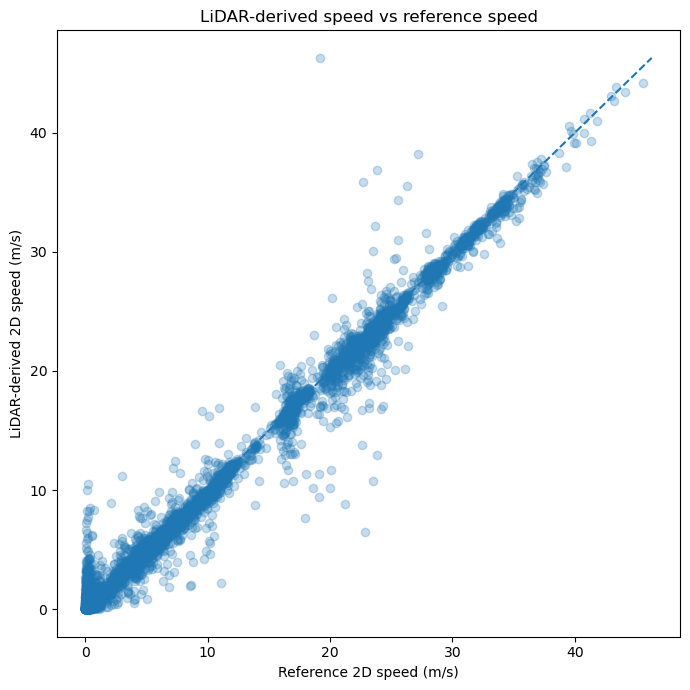

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    lidar_velocity_eval_df["speed_2d_mps"],
    lidar_velocity_eval_df[
        "lidar_speed_2d_mps"
    ],
    alpha=0.25,
)

max_speed = max(
    lidar_velocity_eval_df["speed_2d_mps"].max(),
    lidar_velocity_eval_df[
        "lidar_speed_2d_mps"
    ].max(),
)

plt.plot(
    [0, max_speed],
    [0, max_speed],
    linestyle="--",
)

plt.xlabel(
    "Reference 2D speed (m/s)"
)

plt.ylabel(
    "LiDAR-derived 2D speed (m/s)"
)

plt.title(
    "LiDAR-derived speed vs reference speed"
)

plt.tight_layout()
plt.show()

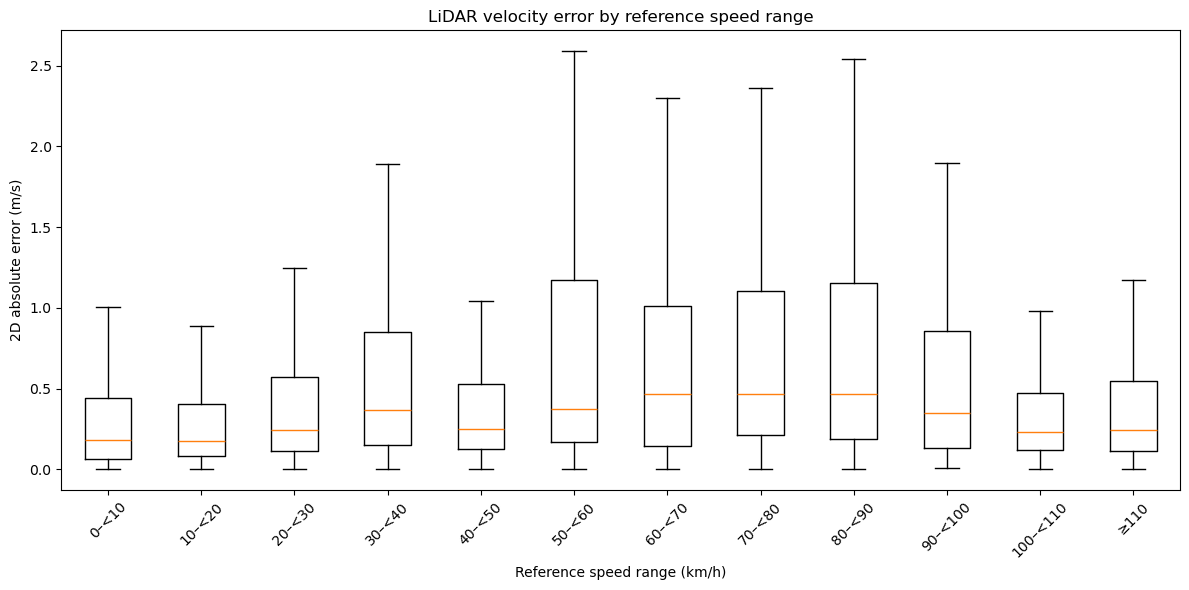

In [18]:
plot_data = [
    lidar_velocity_eval_df.loc[
        lidar_velocity_eval_df[
            "speed_range"
        ] == label,
        "abs_error_2d_mps",
    ].values
    for label in speed_labels
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    plot_data,
    labels=speed_labels,
    showfliers=False,
)

plt.xlabel(
    "Reference speed range (km/h)"
)

plt.ylabel(
    "2D absolute error (m/s)"
)

plt.title(
    "LiDAR velocity error by reference speed range"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

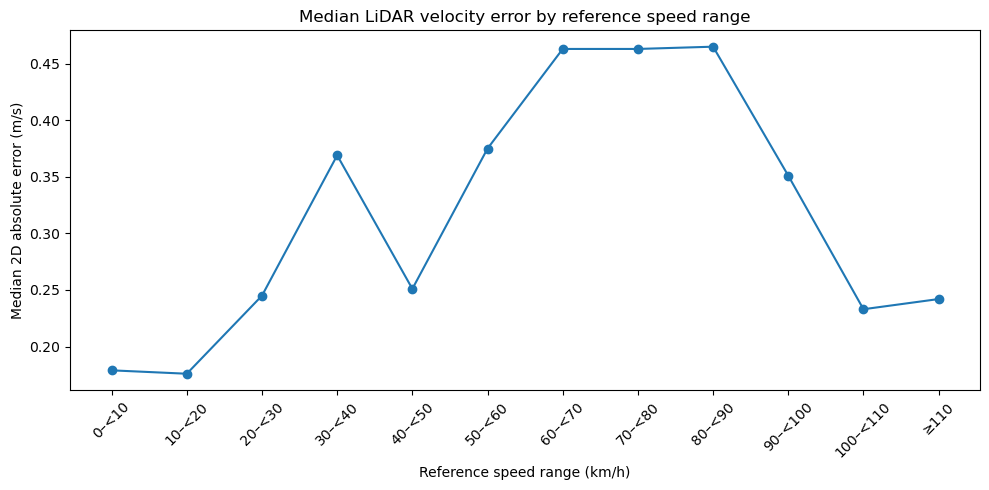

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    lidar_velocity_speed_summary[
        "speed_range"
    ].astype(str),
    lidar_velocity_speed_summary[
        "median_abs_error"
    ],
    marker="o",
)

plt.xlabel(
    "Reference speed range (km/h)"
)

plt.ylabel(
    "Median 2D absolute error (m/s)"
)

plt.title(
    "Median LiDAR velocity error by reference speed range"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Section Summary

A total of 8,007 LiDAR-derived velocity intervals were successfully aligned with the annotation-derived reference velocity, corresponding to 50.86% of the 15,743 valid vehicle reference intervals.

This percentage represents the availability of the current LiDAR velocity-estimation baseline rather than general LiDAR sensor availability. A valid estimate requires consecutive observations from the same LiDAR channel with at least 20 target-associated points at both ends of the interval.

The LiDAR-derived velocity showed close overall agreement with the reference velocity. The median 2D absolute error was approximately 0.224 m/s, while the mean absolute error was approximately 0.510 m/s. The higher mean error indicates that a smaller number of intervals produce substantially larger estimation errors.

The 3D results were similar, with a median absolute error of approximately 0.214 m/s. The 2D ground-plane speed remains the primary metric because vehicle motion is primarily evaluated in the ground plane.

Velocity error varied across the common reference-speed ranges. Median error was generally higher in the intermediate-to-high speed ranges, particularly around 60–90 km/h, but the relationship was not monotonic. Reference speed alone therefore does not explain the variation in LiDAR velocity-estimation error.

Overall, the results show that target motion can be estimated from consecutive TruckScenes LiDAR observations even though the LiDAR files contain no direct velocity field. However, the method depends on sufficient same-sensor point support and remains sensitive to changes in the observed target point distribution.

## 7. Analyse LiDAR Information by Reference Speed Range

This section examines how target-level LiDAR information varies under different annotation-derived vehicle-speed conditions.

The same speed ranges used in the previous notebooks are retained so that the LiDAR analysis remains directly comparable with the RADAR-side workflow.

In [20]:
speed_bins = [
    0, 10, 20, 30, 40, 50, 60,
    70, 80, 90, 100, 110, float("inf")
]

speed_labels = [
    "0–<10",
    "10–<20",
    "20–<30",
    "30–<40",
    "40–<50",
    "50–<60",
    "60–<70",
    "70–<80",
    "80–<90",
    "90–<100",
    "100–<110",
    "≥110",
]

lidar_speed_df["speed_2d_kmh"] = (
    lidar_speed_df["speed_2d_mps"] * 3.6
)

lidar_speed_df["speed_range"] = pd.cut(
    lidar_speed_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
)

lidar_speed_summary = (
    lidar_speed_df
    .groupby("speed_range", observed=False)
    .agg(
        target_observations=("annotation_token", "size"),
        median_lidar_points=("lidar_point_count", "median"),
        mean_lidar_points=("lidar_point_count", "mean"),
        min_lidar_points=("lidar_point_count", "min"),
        max_lidar_points=("lidar_point_count", "max"),
    )
    .round(2)
    .reset_index()
)

display(lidar_speed_summary)

,speed_range,target_observations,median_lidar_points,mean_lidar_points,min_lidar_points,max_lidar_points
0,0–<10,6870,64.0,1130.63,1,50870
1,10–<20,2028,59.0,1015.70,1,50999
2,20–<30,1211,30.0,642.81,1,42311
3,30–<40,799,28.0,460.58,1,21772
4,40–<50,510,16.0,170.22,1,14818
5,50–<60,424,17.0,595.91,1,14081
6,60–<70,542,39.0,423.56,1,12890
7,70–<80,823,28.0,442.23,1,20081
8,80–<90,797,58.0,488.71,1,10727
9,90–<100,411,20.0,184.28,1,6987


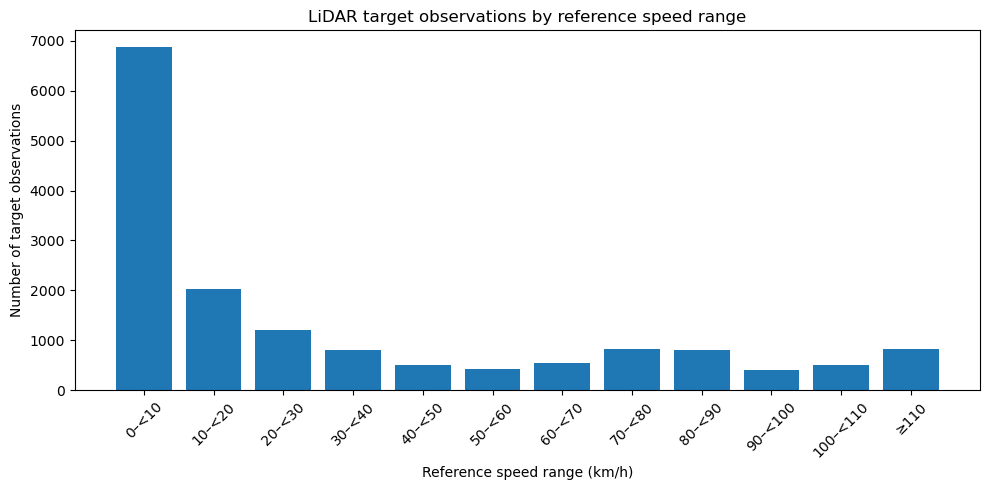

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(
    lidar_speed_summary["speed_range"].astype(str),
    lidar_speed_summary["target_observations"],
)
plt.xlabel("Reference speed range (km/h)")
plt.ylabel("Number of target observations")
plt.title("LiDAR target observations by reference speed range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

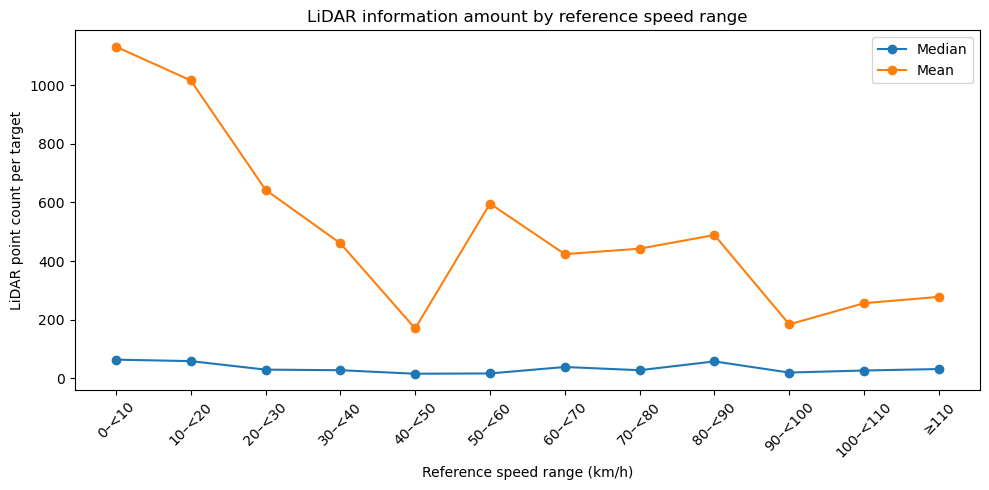

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(
    lidar_speed_summary["speed_range"].astype(str),
    lidar_speed_summary["median_lidar_points"],
    marker="o",
    label="Median",
)
plt.plot(
    lidar_speed_summary["speed_range"].astype(str),
    lidar_speed_summary["mean_lidar_points"],
    marker="o",
    label="Mean",
)
plt.xlabel("Reference speed range (km/h)")
plt.ylabel("LiDAR point count per target")
plt.title("LiDAR information amount by reference speed range")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

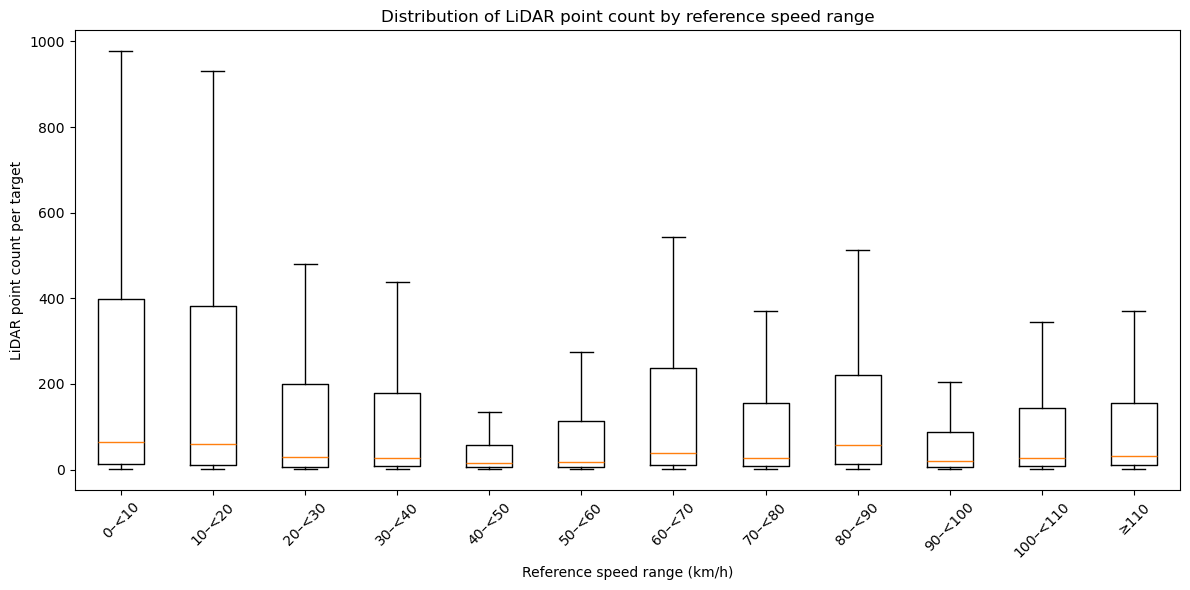

In [23]:
plot_data = [
    lidar_speed_df.loc[
        lidar_speed_df["speed_range"] == label,
        "lidar_point_count"
    ].values
    for label in speed_labels
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    plot_data,
    labels=speed_labels,
    showfliers=False,
)

plt.xlabel("Reference speed range (km/h)")
plt.ylabel("LiDAR point count per target")
plt.title("Distribution of LiDAR point count by reference speed range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

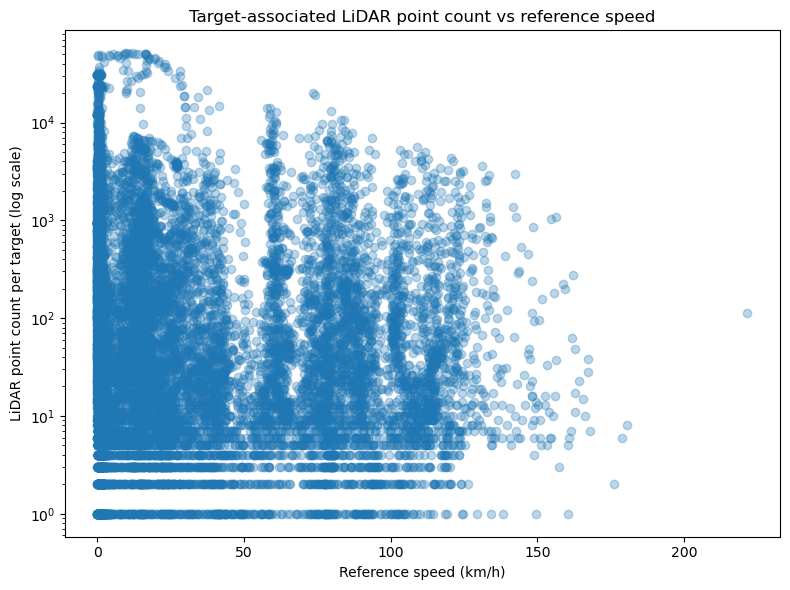

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    lidar_speed_df["speed_2d_kmh"],
    lidar_speed_df["lidar_point_count"],
    alpha=0.3,
)

plt.yscale("log")

plt.xlabel("Reference speed (km/h)")
plt.ylabel("LiDAR point count per target (log scale)")
plt.title("Target-associated LiDAR point count vs reference speed")

plt.tight_layout()
plt.show()

### Section Summary

LiDAR target observations are unevenly distributed across reference-speed ranges, with the largest number of observations occurring in the lowest-speed range.

Target-associated LiDAR point counts vary substantially across all speed conditions. Mean point counts are consistently higher than median values, indicating strongly right-skewed distributions with some very large point-count observations.

Lower-speed ranges generally contain more LiDAR points per target, but the relationship between reference speed and LiDAR point count is not monotonic. Considerable variation remains within each speed range, showing that reference speed alone does not determine the amount of LiDAR information associated with a target.

Therefore, LiDAR point count is used as a measure of target-associated information amount, rather than as a direct vehicle-velocity measurement.

## 8. Summary and Limitations

This notebook examined both LiDAR-derived vehicle velocity and target-associated LiDAR information in TruckScenes.

The LiDAR PCD files contain x, y, z, intensity, and point-level timestamp information, but no direct velocity field. Vehicle velocity was therefore estimated from changes in LiDAR-derived target position across consecutive keyframes rather than read directly from the sensor data.

Keyframe LiDAR observations were found to be closely aligned with their linked annotation samples. Direct point-in-box counting across the six raw LiDAR sensors did not exactly reproduce the metadata `num_lidar_pts` values, and point-level timestamps showed that individual LiDAR scans span several tens of milliseconds around the annotation sample time. The dataset-provided `num_lidar_pts` field was therefore retained for the target-level information-amount analysis.

For velocity estimation, annotation boxes were used only to associate LiDAR points with target vehicles. Target position was estimated from the mean global position of the associated LiDAR points. Consecutive observations from the same LiDAR channel were paired, and at least 20 target-associated points were required at both ends of each interval. When multiple LiDAR channels satisfied this requirement, the channel with the strongest minimum point support was selected.

The final workflow produced 8,007 LiDAR-derived velocity intervals covering 514 unique target vehicles. These estimates were available for 50.86% of the 15,743 valid annotation-derived reference intervals. This percentage represents the availability of the current LiDAR velocity-estimation method rather than general LiDAR sensor availability.

The LiDAR-derived velocity showed close overall agreement with the annotation-derived reference velocity. The median 2D absolute error was approximately 0.224 m/s and the mean 2D absolute error was approximately 0.510 m/s. The median 3D absolute error was approximately 0.214 m/s. Velocity error varied across reference-speed ranges but did not increase monotonically with vehicle speed.

The target-level information analysis identified 16,501 vehicle observations representing 758 unique target vehicles. Of these, 15,743 observations covering 750 vehicles were linked to valid reference-speed intervals. Target-associated LiDAR point counts showed strongly right-skewed distributions and substantial variation across speed conditions. Lower-speed ranges generally contained more LiDAR points per target, but reference speed alone did not determine the amount of LiDAR information available.

The current velocity baseline is limited to keyframe observations and requires sufficient same-sensor point support across consecutive observations. It does not use intermediate sweeps, point-level ego-motion compensation, or annotation interpolation. The LiDAR-derived target position may also vary as the visible target surface and point distribution change between observations, which can produce larger velocity-estimation errors in some intervals.

The resulting LiDAR velocity estimates, velocity availability, target-associated information amount, and information type will be used in the later RADAR–LiDAR comparison.

In [25]:
from pathlib import Path

RESULTS_ROOT = Path("../results/validated")

target_lidar_df.to_pickle(
    RESULTS_ROOT / "target_lidar_df.pkl"
)

lidar_velocity_df.to_pickle(
    RESULTS_ROOT / "lidar_velocity_df.pkl"
)

print("Saved target_lidar_df.pkl")
print("LiDAR target rows:", len(target_lidar_df))

print("Saved lidar_velocity_df.pkl")
print("LiDAR velocity intervals:", len(lidar_velocity_df))

Saved target_lidar_df.pkl
LiDAR target rows: 16501
Saved lidar_velocity_df.pkl
LiDAR velocity intervals: 8007
